# What is Pneumonia?
**Pneumonia is an inflammatory condition of the lung affecting primarily the small air sacs known as alveoli.Symptoms typically include some combination of productive or dry cough, chest pain, fever and difficulty breathing. The severity of the condition is variable. Pneumonia is usually caused by infection with viruses or bacteria and less commonly by other microorganisms, certain medications or conditions such as autoimmune diseases.Risk factors include cystic fibrosis, chronic obstructive pulmonary disease (COPD), asthma, diabetes, heart failure, a history of smoking, a poor ability to cough such as following a stroke and a weak immune system. Diagnosis is often based on symptoms and physical examination. Chest X-ray, blood tests, and culture of the sputum may help confirm the diagnosis.The disease may be classified by where it was acquired, such as community- or hospital-acquired or healthcare-associated pneumonia.**
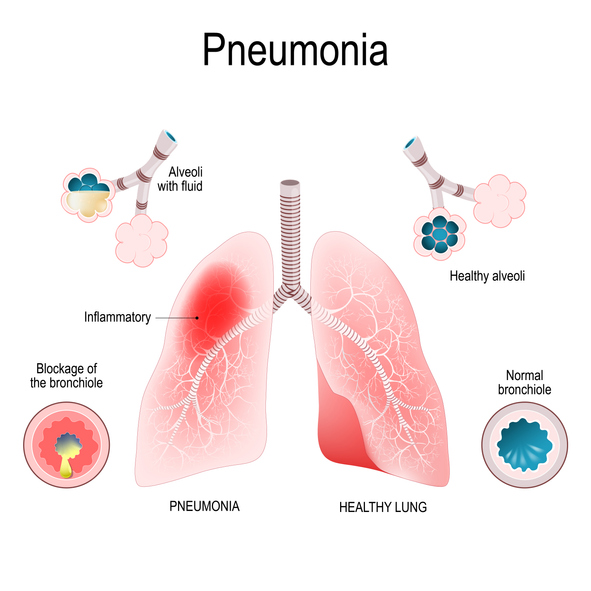

In [138]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

# Importing the necessary libraries

In [139]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Description of the Pneumonia Dataset
**The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).
Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.
For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.**

In [140]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150

def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is None:
                    continue
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
    return np.array(data, dtype=object)

# Loading the Dataset

In [141]:
# using disk cache to speed up subseqeunt runs and avoid preprocessing every time
from pathlib import Path

img_size = 150
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / f"chest_xray_{img_size}_v1.npz"

if CACHE_FILE.exists():
    print(f"Loading cached arrays from: {CACHE_FILE}")
    data = np.load(CACHE_FILE)
    x_train, y_train = data["x_train"], data["y_train"]
    x_val, y_val = data["x_val"], data["y_val"]
    x_test, y_test = data["x_test"], data["y_test"]
else:
    print("Cache not found, building arrays from images...")

    # existing loaders
    train = get_training_data(r".\chest_xray\train")
    val = get_training_data(r".\chest_xray\val")
    test = get_training_data(r".\chest_xray\test")

    x_train, y_train = zip(*train)
    x_val, y_val = zip(*val)
    x_test, y_test = zip(*test)

    x_train = np.array(x_train, dtype=np.float32).reshape(-1, img_size, img_size, 1) / 255.0
    x_val = np.array(x_val, dtype=np.float32).reshape(-1, img_size, img_size, 1) / 255.0
    x_test = np.array(x_test, dtype=np.float32).reshape(-1, img_size, img_size, 1) / 255.0

    y_train = np.array(y_train, dtype=np.int32)
    y_val = np.array(y_val, dtype=np.int32)
    y_test = np.array(y_test, dtype=np.int32)

    np.savez(CACHE_FILE,
             x_train=x_train, y_train=y_train,
             x_val=x_val, y_val=y_val,
             x_test=x_test, y_test=y_test)
    print(f"Saved cache to: {CACHE_FILE}")

print("x_train:", x_train.shape, "x_val:", x_val.shape, "x_test:", x_test.shape)

Loading cached arrays from: cache\chest_xray_150_v1.npz
x_train: (5216, 150, 150, 1) x_val: (16, 150, 150, 1) x_test: (624, 150, 150, 1)


In [142]:
# # TODO: add your own paths here
# train = get_training_data(r".\chest_xray\train")
# test = get_training_data(r".\chest_xray\test")
# val = get_training_data(r".\chest_xray\val")

# Data Visualization & Preprocessing

<Axes: ylabel='count'>

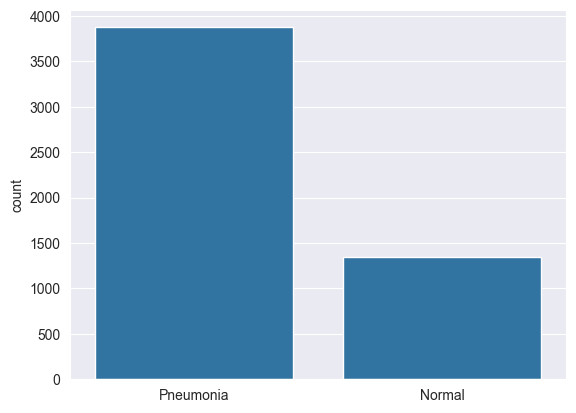

In [143]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Pneumonia")
    else:
        l.append("Normal")
sns.set_style('darkgrid')
sns.countplot(x=l)

**The data seems imbalanced . To increase the no. of training examples, we will use data augmentation**

**Previewing the images of both the classes**

Text(0.5, 1.0, 'NORMAL')

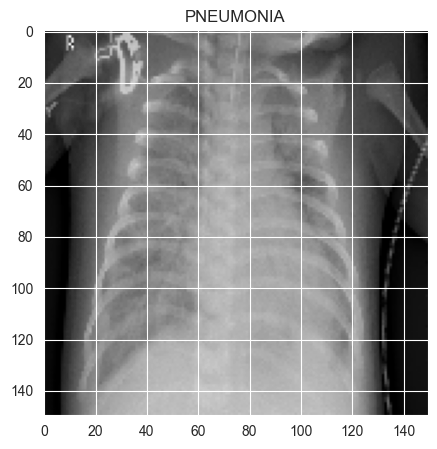

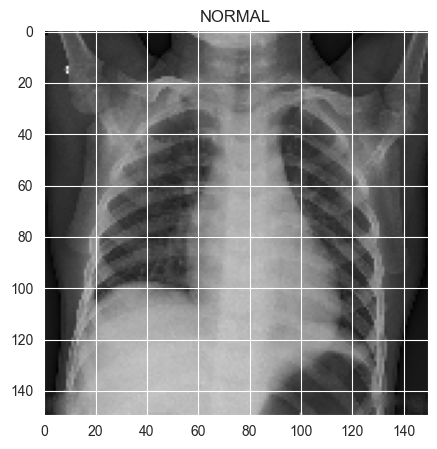

In [144]:
# plt.figure(figsize = (5,5))
# plt.imshow(train[0][0], cmap='gray')
# plt.title(labels[train[0][1]])

# plt.figure(figsize = (5,5))
# plt.imshow(train[-1][0], cmap='gray')
# plt.title(labels[train[-1][1]])

# fixing these so they work with cached arrays
plt.figure(figsize=(5,5))
plt.imshow(x_train[0].squeeze(), cmap='gray')
plt.title(labels[int(y_train[0])])

plt.figure(figsize=(5,5))
plt.imshow(x_train[-1].squeeze(), cmap='gray')
plt.title(labels[int(y_train[-1])])

In [145]:
# x_train = []
# y_train = []

# x_val = []
# y_val = []

# x_test = []
# y_test = []

# for feature, label in train:
#     x_train.append(feature)
#     y_train.append(label)

# for feature, label in test:
#     x_test.append(feature)
#     y_test.append(label)

# for feature, label in val:
#     x_val.append(feature)
#     y_val.append(label)

# # # preview shapes
# # print(f"x_train shape: {np.array(x_train).shape}")
# # print(f"y_train shape: {np.array(y_train).shape}")
# # print(f"x_val shape: {np.array(x_val).shape}")
# # print(f"y_val shape: {np.array(y_val).shape}")
# # print(f"x_test shape: {np.array(x_test).shape}")
# # print(f"y_test shape: {np.array(y_test).shape}")

**We perform a grayscale normalization to reduce the effect of illumination's differences.Moreover the CNN converges faster on [0..1] data than on [0..255].**

In [146]:
# # Normalize the data
# x_train = np.array(x_train) / 255
# x_val = np.array(x_val) / 255
# x_test = np.array(x_test) / 255

In [147]:
# resize data for deep learning
x_train = x_train.reshape(-1, img_size, img_size, 1)
y_train = np.array(y_train)
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")

x_val = x_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")

x_test = x_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (5216, 150, 150, 1)
y_train shape: (5216,)
x_val shape: (16, 150, 150, 1)
y_val shape: (16,)
x_test shape: (624, 150, 150, 1)
y_test shape: (624,)


# Data Augmentation
**In order to avoid overfitting problem, we need to expand artificially our dataset. We can make your existing dataset even larger. The idea is to alter the training data with small transformations to reproduce the variations.
Approaches that alter the training data in ways that change the array representation while keeping the label the same are known as data augmentation techniques. Some popular augmentations people use are grayscales, horizontal flips, vertical flips, random crops, color jitters, translations, rotations, and much more.
By applying just a couple of these transformations to our training data, we can easily double or triple the number of training examples and create a very robust model.**

In [148]:
# With data augmentation to prevent overfitting and handling the imbalance in dataset

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(x_train)

For the data augmentation, i choosed to :
1. Randomly rotate some training images by 30 degrees 
2. Randomly Zoom by 20% some training images
3. Randomly shift images horizontally by 10% of the width 
4. Randomly shift images vertically by 10% of the height 
5. Randomly flip images horizontally.
Once our model is ready, we fit the training dataset.

# Training the Model

In [149]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(256 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1 , activation = 'sigmoid'))
model.compile(optimizer = "rmsprop" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_25 (Conv2D)          (None, 150, 150, 32)      320       
                                                                 
 batch_normalization_25 (Bat  (None, 150, 150, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_25 (MaxPoolin  (None, 75, 75, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_26 (Conv2D)          (None, 75, 75, 64)        18496     
                                                                 
 dropout_20 (Dropout)        (None, 75, 75, 64)        0         
                                                                 
 batch_normalization_26 (Bat  (None, 75, 75, 64)      

In [150]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

In [151]:
# history = model.fit(datagen.flow(x_train,y_train, batch_size = 32) ,epochs = 12 , validation_data = datagen.flow(x_val, y_val) ,callbacks = [learning_rate_reduction])

In [152]:
# replacing the model.fit() cell so we won't have to wait for the baseline to train
import time, os

RUN_BASELINE_TRAINING = False  # True = train, False = load saved model
FORCE_RUN_ID = None
ARTIFACT_ROOT = Path("artifacts")

def _latest_run(root: Path):
    runs = [p for p in root.iterdir() if p.is_dir() and (p / "model.keras").exists()]
    if not runs:
        raise FileNotFoundError("No saved runs with model.keras found in artifacts/")
    return max(runs, key=lambda p: p.stat().st_mtime)

if RUN_BASELINE_TRAINING:
    history = model.fit(
        datagen.flow(x_train, y_train, batch_size=32),
        epochs=12,
        validation_data=datagen.flow(x_val, y_val),
        callbacks=[learning_rate_reduction]
    )

    run_id = time.strftime("baseline_%Y%m%d_%H%M%S")
    out = ARTIFACT_ROOT / run_id
    out.mkdir(parents=True, exist_ok=True)

    model.save(out / "model.keras")
    pd.DataFrame(history.history).to_csv(out / "history.csv", index=False)
    print(f"Trained and saved to: {out}")

else:
    run_dir = ARTIFACT_ROOT / FORCE_RUN_ID if FORCE_RUN_ID else _latest_run(ARTIFACT_ROOT)
    model = tf.keras.models.load_model(run_dir / "model.keras")
    print(f"Loaded model from: {run_dir}")

    # make 'history' available so that any plot cells using history.history still work
    history_csv = run_dir / "history.csv"
    if history_csv.exists():
        _hist_df = pd.read_csv(history_csv)
        class _History: pass
        history = _History()
        history.history = {c: _hist_df[c].tolist() for c in _hist_df.columns}

Loaded model from: artifacts\baseline_20260315_131804


In [153]:
print("Loss of the model is - " , model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(x_test,y_test)[1]*100 , "%")

20/20 [==============================] - 2s 86ms/step - loss: 0.2716 - accuracy: 0.9103
Loss of the model is -  0.271634578704834
20/20 [==============================] - 2s 87ms/step - loss: 0.2716 - accuracy: 0.9103
Accuracy of the model is -  91.02563858032227 %


# Analysis after Model Training

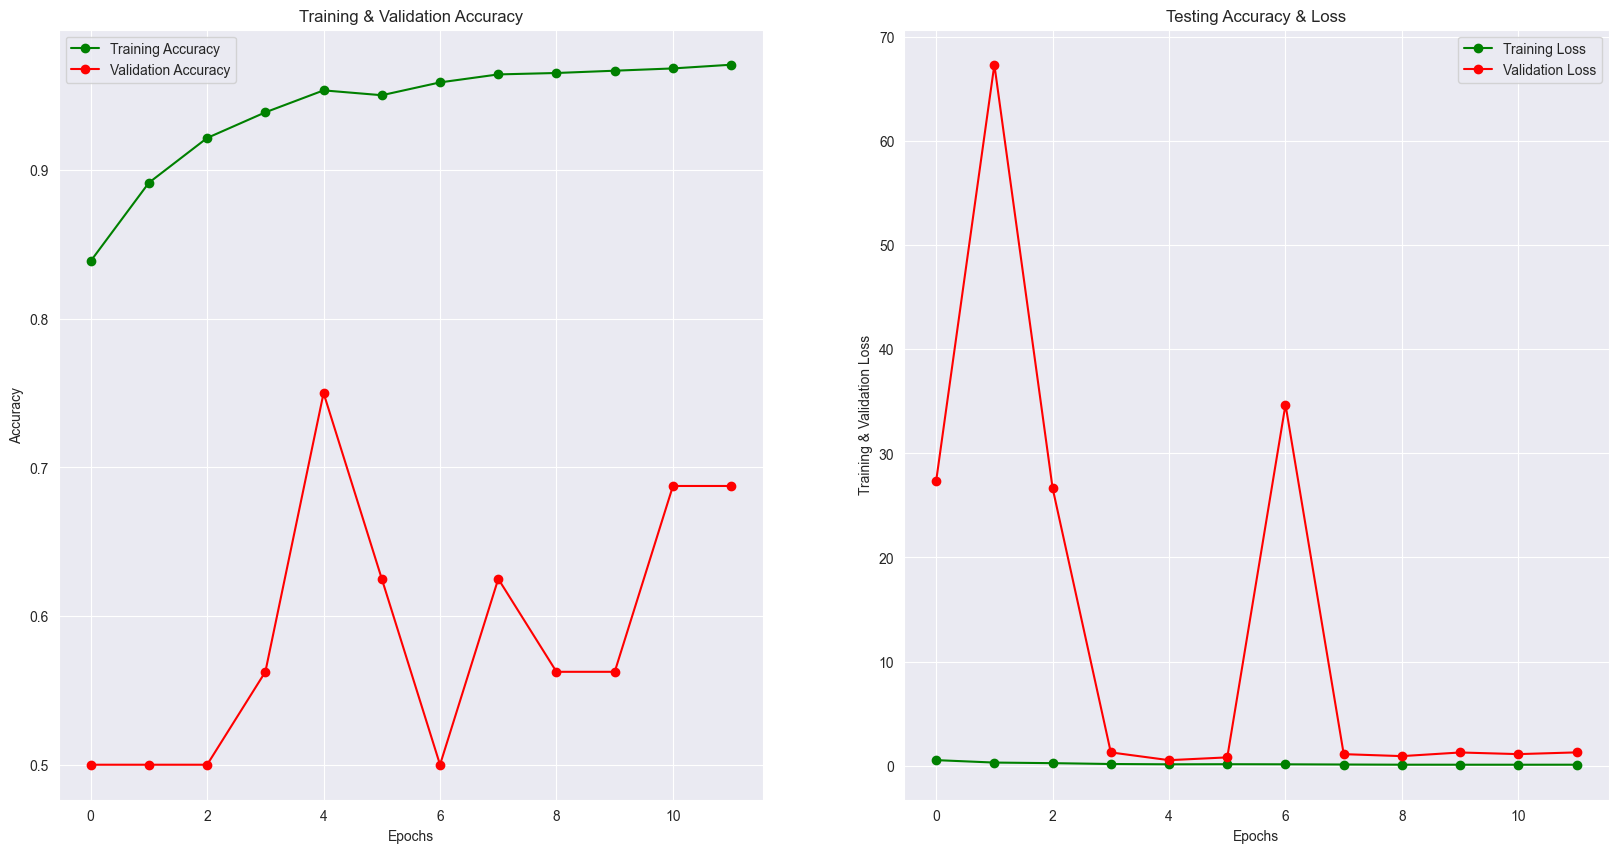

In [154]:
epochs = [i for i in range(12)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Training & Validation Loss")
plt.show()

In [155]:
predictions = model.predict(x_test)
predicted_classes = (predictions > 0.5).astype("int32")
predicted_classes[:15]

20/20 [==============================] - 2s 86ms/step


array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [156]:
print(classification_report(y_test, predicted_classes, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.93      0.93      0.93       390
   Normal (Class 1)       0.88      0.88      0.88       234

           accuracy                           0.91       624
          macro avg       0.90      0.91      0.90       624
       weighted avg       0.91      0.91      0.91       624



In [157]:
cm = confusion_matrix(y_test, predicted_classes)
cm


array([[361,  29],
       [ 27, 207]], dtype=int64)

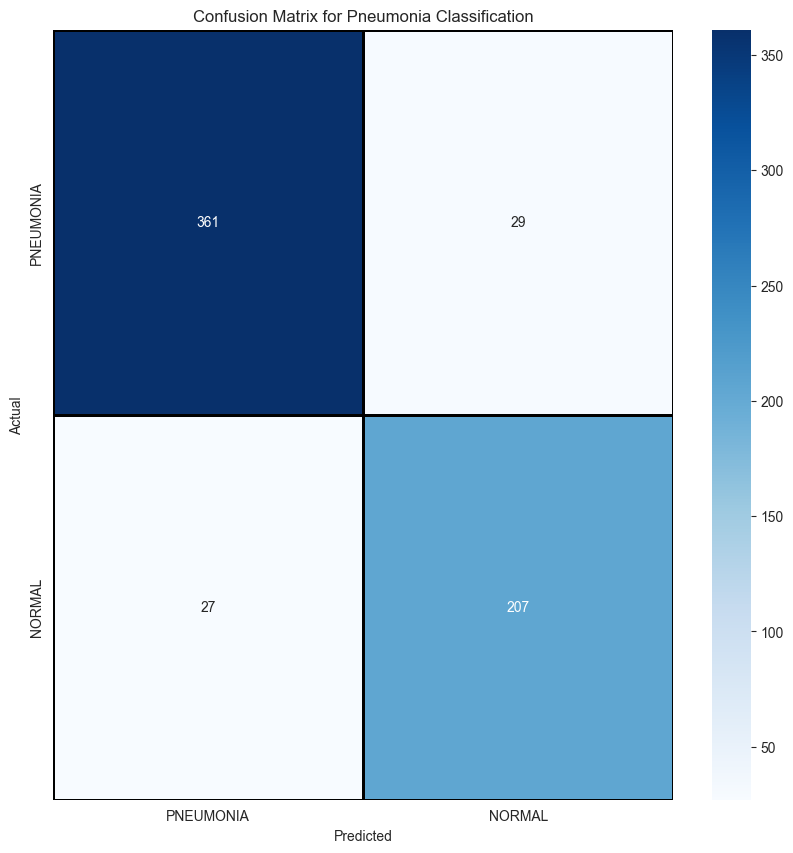

In [158]:
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])

plt.figure(figsize=(10, 10))
sns.heatmap(cm, cmap="Blues", linecolor='black', linewidth=1,
         annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Pneumonia Classification")
plt.show()


- There is a bug in the Seaborn library version being used (`0.12.0`), which causes only the top value to be filled in.  
- Unfortunately, the Seaborn library can't be updated since it conflicts with other dependencies.  
- So there is no quick fix for this — only creating the plot in a separate file using the up-to-date Seaborn library.  
- Run `pip install seaborn --upgrade` in a different environment to create a proper plot.


In [159]:
# correct = np.nonzero(predictions == y_test)[0]
# incorrect = np.nonzero(predictions != y_test)[0]

predictions = model.predict(x_test, verbose=0).ravel()
y_pred = (predictions > 0.5).astype(int)
y_true = y_test.astype(int).ravel()

correct = np.where(y_pred == y_true)[0]
incorrect = np.where(y_pred != y_true)[0]

**Some of the Correctly Predicted Classes**

C:\Users\pavel\AppData\Local\Temp\ipykernel_27964\681850414.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3,2,i+1)


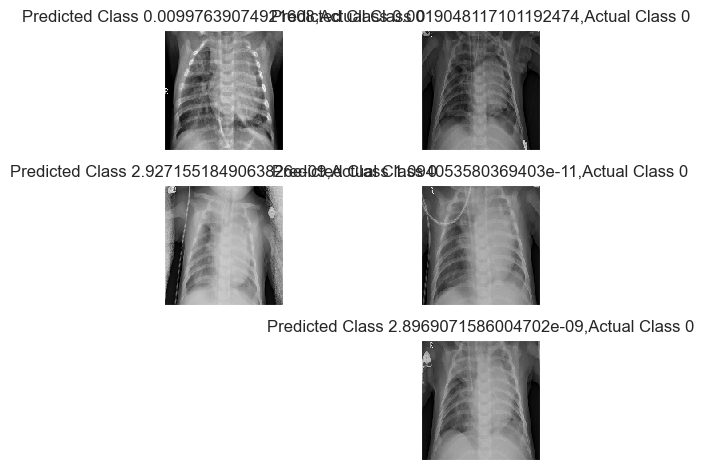

In [160]:
i = 0
for c in correct[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

**Some of the Incorrectly Predicted Classes**

C:\Users\pavel\AppData\Local\Temp\ipykernel_27964\344158187.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3,2,i+1)


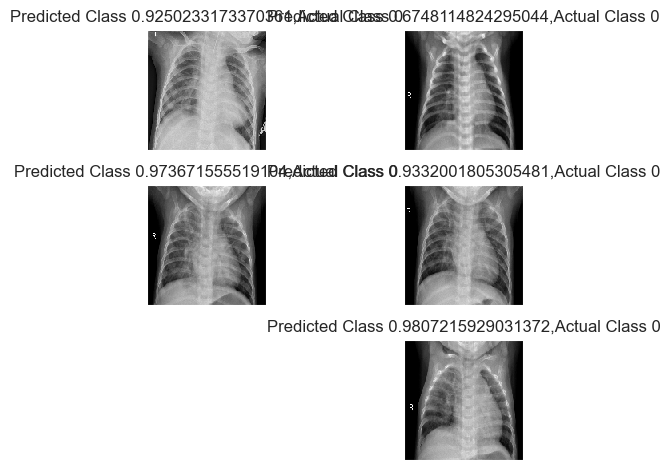

In [161]:
i = 0
for c in incorrect[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

In [162]:
import json
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

# eval baseline
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

# predict -> class labels
y_prob = model.predict(x_test, verbose=0).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_true = y_test.astype(int).ravel()

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", pos_label=1
)
cm = confusion_matrix(y_true, y_pred)

print(f"test_loss:{test_loss:.4f}")
print(f"test_acc: {test_acc:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print(f"f1: {f1:.4f}")
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=["Pneumonia (0)", "Normal (1)"]))

# save artifacts
run_id = time.strftime("baseline_%Y%m%d_%H%M%S")
out = os.path.join("artifacts", run_id)
os.makedirs(out, exist_ok=True)

# training history
if "history" in globals() and hasattr(history, "history"):
    pd.DataFrame(history.history).to_csv(os.path.join(out, "history.csv"), index=False)

# model + predictions + metrics
model.save(os.path.join(out, "model.keras"))
pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}).to_csv(
    os.path.join(out, "predictions.csv"), index=False
)
pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"]).to_csv(
    os.path.join(out, "confusion_matrix.csv")
)

metrics = {
    "test_loss": float(test_loss),
    "test_acc": float(test_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
}
with open(os.path.join(out, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print(f"\nSaved baseline artifacts to: {out}")

test_loss:0.2716
test_acc: 0.9103
precision: 0.8771
recall: 0.8846
f1: 0.8809

Classification report:

               precision    recall  f1-score   support

Pneumonia (0)       0.93      0.93      0.93       390
   Normal (1)       0.88      0.88      0.88       234

     accuracy                           0.91       624
    macro avg       0.90      0.91      0.90       624
 weighted avg       0.91      0.91      0.91       624


Saved baseline artifacts to: artifacts\baseline_20260315_131939
